# Phase 3 - Flight Delay Project (EDA + Preprocessing)

---

## Project Overview

In this project we build a data science pipeline about **airport punctuality and flight delays** in Europe.
Our unit of analysis is an **airport-day record**: each row is one airport on one date, with its punctuality
and average delay numbers for that day. We chose this unit because the EUROCONTROL dataset is reported daily
per airport, and it lets us reach far more than 1,000 rows while staying simple and reproducible.

We focus on **5 countries**: France (FR), Germany (DE), Spain (ES), Italy (IT) and the Netherlands (NL).

## Data Sources

1. **EUROCONTROL Daily Airport Punctuality** (`eurocontrol_punctuality.csv`) - daily departure/arrival
   punctuality % and average schedule delay per airport.
2. **OurAirports metadata** (`ourairports_airports.csv`) - airport type, country, city, latitude,
   longitude, elevation, scheduled-service flag.

We merge them so each airport-day row also carries airport metadata. This is how we reach **15+ features**.

> **Reproducibility Statement:** All raw files are stored under `data/raw/` and the notebook runs
> end-to-end without manual downloads or path changes.

## Step 1 - Load the Data

We load both raw CSV files and print their shapes so we know how much data we start with.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

TARGET_ISO = ["FR", "DE", "ES", "IT", "NL"]

eurocontrol_raw = pd.read_csv("eurocontrol_punctuality.csv")
ourairports_raw = pd.read_csv("ourairports_airports.csv")

print("EUROCONTROL raw shape:", eurocontrol_raw.shape)
print("OurAirports raw shape:", ourairports_raw.shape)

EUROCONTROL raw shape: (51419, 8)
OurAirports raw shape: (85484, 19)


In [31]:
print("EUROCONTROL head:")
display(eurocontrol_raw.head())

print("OurAirports head:")
display(ourairports_raw.head())

EUROCONTROL head:


,Date,Airport,Departure Punctuality %,Arrival Punctuality %,Avg Departure Schedule Delay,Avg Arrival Schedule Delay,Avg Departure - Arrival Schedule Delay,Operated Schedules %
0,2022-01-01,Brussels,81.63%,77.63%,12.700680,12.238487,0.462193,89.70%
1,2022-01-02,Brussels,70.19%,69.90%,15.014423,16.865391,-1.850968,91.81%
2,2022-01-03,Brussels,72.12%,75.47%,12.394231,11.233884,1.160347,94.14%
3,2022-01-04,Brussels,80.75%,80.95%,15.807487,14.900088,0.907398,89.30%
4,2022-01-05,Brussels,87.82%,82.59%,9.416244,8.678358,0.737885,97.07%


OurAirports head:


,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,iso_country,iso_region,municipality,scheduled_service,icao_code,iata_code,gps_code,local_code,home_link,wikipedia_link,keywords
0,6523,00A,heliport,Total RF Heliport,40.070985,-74.933689,11.0,NaN,US,US-PA,Bensalem,no,NaN,NaN,K00A,00A,https://www.penndot.pa.gov/TravelInPA/airports...,NaN,NaN
1,323361,00AA,small_airport,Aero B Ranch Airport,38.704022,-101.473911,3435.0,NaN,US,US-KS,Leoti,no,NaN,NaN,00AA,00AA,NaN,NaN,NaN
2,6524,00AK,small_airport,Lowell Field,59.947733,-151.692524,450.0,NaN,US,US-AK,Anchor Point,no,NaN,NaN,00AK,00AK,NaN,NaN,NaN
3,6525,00AL,small_airport,Epps Airpark,34.864799,-86.770302,820.0,NaN,US,US-AL,Harvest,no,NaN,NaN,00AL,00AL,NaN,NaN,NaN
4,506791,00AN,small_airport,Katmai Lodge Airport,59.093287,-156.456699,80.0,NaN,US,US-AK,King Salmon,no,NaN,NaN,00AN,00AN,NaN,NaN,NaN


## Step 2 - Map City Names to Airport Codes (Manual Dictionary)

**The problem:** the EUROCONTROL `Airport` column uses **city names** (e.g. "Brussels", "Paris"),
but OurAirports identifies airports by **IATA code** (e.g. "BRU", "CDG"). We cannot merge them directly.

**Our simple solution:** instead of fancy text matching, we write a small dictionary by hand that maps
each EUROCONTROL city name to its main international airport IATA code. This is easy to read, easy to
explain, and avoids any complicated string libraries. We only need the airports that appear in our
5 target countries.

In [32]:
city_to_iata = {
    # France
    "Paris": "CDG", "Paris CDG": "CDG", "Paris Orly": "ORY", "Nice": "NCE",
    "Lyon": "LYS", "Marseille": "MRS", "Toulouse": "TLS", "Bordeaux": "BOD",
    "Nantes": "NTE",
    # Germany
    "Frankfurt": "FRA", "Munich": "MUC", "Berlin": "BER", "Dusseldorf": "DUS",
    "Hamburg": "HAM", "Cologne": "CGN", "Stuttgart": "STR", "Hannover": "HAJ",
    # Spain
    "Madrid": "MAD", "Barcelona": "BCN", "Palma": "PMI", "Palma de Mallorca": "PMI",
    "Malaga": "AGP", "Alicante": "ALC", "Valencia": "VLC", "Seville": "SVQ",
    "Gran Canaria": "LPA", "Tenerife": "TFS",
    # Italy
    "Rome": "FCO", "Milan": "MXP", "Milan Malpensa": "MXP", "Milan Linate": "LIN",
    "Venice": "VCE", "Naples": "NAP", "Bologna": "BLQ", "Catania": "CTA",
    "Bergamo": "BGY",
    # Netherlands
    "Amsterdam": "AMS", "Eindhoven": "EIN", "Rotterdam": "RTM",
}

print("Number of city -> IATA mappings:", len(city_to_iata))

Number of city -> IATA mappings: 39


In [33]:
euro = eurocontrol_raw.copy()
euro["Airport"] = euro["Airport"].astype(str).str.strip()
euro["iata_code"] = euro["Airport"].map(city_to_iata)

matched = euro["iata_code"].notna().mean()
print("Share of EUROCONTROL rows we could map to an IATA code:", round(matched, 3))
euro = euro[euro["iata_code"].notna()].copy()
print("Rows after keeping mapped airports:", euro.shape[0])

Share of EUROCONTROL rows we could map to an IATA code: 0.281
Rows after keeping mapped airports: 14462


## Step 3 - Merge with Airport Metadata

Now both tables share an `iata_code` column, so we can merge them. We keep only OurAirports rows that
have a real IATA code, then do a **left join** so every EUROCONTROL airport-day row gets its airport
metadata (country, type, latitude, longitude, elevation, etc.).

In [34]:
air = ourairports_raw.copy()
air["iata_code"] = air["iata_code"].astype(str).str.strip().str.upper()
air = air[(air["iata_code"].notna()) & (air["iata_code"] != "") & (air["iata_code"] != "NAN")].copy()
air_cols = ["iata_code", "name", "municipality", "iso_country", "type",
            "scheduled_service", "latitude_deg", "longitude_deg", "elevation_ft"]
air = air[air_cols].drop_duplicates(subset=["iata_code"]).copy()

print("OurAirports rows with IATA code:", air.shape[0])

OurAirports rows with IATA code: 9057


In [35]:
merged = euro.merge(air, on="iata_code", how="left")

print("Merged shape:", merged.shape)
print("Match rate (rows that found metadata):", round(merged["iso_country"].notna().mean(), 3))
merged.head()

Merged shape: (14462, 17)
Match rate (rows that found metadata): 1.0


,Date,Airport,Departure Punctuality %,Arrival Punctuality %,Avg Departure Schedule Delay,Avg Arrival Schedule Delay,Avg Departure - Arrival Schedule Delay,Operated Schedules %,iata_code,name,municipality,iso_country,type,scheduled_service,latitude_deg,longitude_deg,elevation_ft
0,2022-01-01,Frankfurt,81.89%,80.42%,13.043920,13.426908,-0.382988,92.22%,FRA,Frankfurt Main Airport,Frankfurt am Main,DE,large_airport,yes,50.026706,8.55835,364.0
1,2022-01-02,Frankfurt,70.72%,71.34%,17.652062,18.506590,-0.854528,94.65%,FRA,Frankfurt Main Airport,Frankfurt am Main,DE,large_airport,yes,50.026706,8.55835,364.0
2,2022-01-03,Frankfurt,73.89%,75.60%,16.235140,13.956209,2.278931,95.22%,FRA,Frankfurt Main Airport,Frankfurt am Main,DE,large_airport,yes,50.026706,8.55835,364.0
3,2022-01-04,Frankfurt,63.05%,72.60%,16.605624,14.621955,1.983669,95.38%,FRA,Frankfurt Main Airport,Frankfurt am Main,DE,large_airport,yes,50.026706,8.55835,364.0
4,2022-01-05,Frankfurt,78.28%,82.20%,10.382379,9.699187,0.683192,94.68%,FRA,Frankfurt Main Airport,Frankfurt am Main,DE,large_airport,yes,50.026706,8.55835,364.0


In [36]:
df = merged[merged["iso_country"].isin(TARGET_ISO)].copy()

print("Rows after filtering to 5 countries:", df.shape[0])
print("Countries present:", sorted(df["iso_country"].unique()))

Rows after filtering to 5 countries: 14462
Countries present: ['DE', 'ES', 'FR', 'IT', 'NL']


## Step 4 - Clean the Data

The percentage columns are stored as text like `"81.63%"`, and some numeric columns may be read as text.
We convert them to real numbers. We also parse the date and remove duplicate airport-day records.

In [37]:
pct_cols = [c for c in df.columns if "Punctuality" in c or c.endswith("%")]
print("Percentage columns:", pct_cols)

for c in pct_cols:
    df[c] = df[c].astype(str).str.replace("%", "", regex=False).str.strip()
    df[c] = df[c].replace({"nan": np.nan, "None": np.nan, "": np.nan})
    df[c] = pd.to_numeric(df[c], errors="coerce")

df[pct_cols].head()

Percentage columns: ['Departure Punctuality %', 'Arrival Punctuality %', 'Operated Schedules %']


,Departure Punctuality %,Arrival Punctuality %,Operated Schedules %
0,81.89,80.42,92.22
1,70.72,71.34,94.65
2,73.89,75.60,95.22
3,63.05,72.60,95.38
4,78.28,82.20,94.68


In [38]:
delay_cols = [c for c in df.columns if "Delay" in c or "Schedule" in c]
print("Delay columns:", delay_cols)

for c in delay_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df[delay_cols].head()

Delay columns: ['Avg Departure Schedule Delay', 'Avg Arrival Schedule Delay', 'Avg Departure - Arrival Schedule Delay', 'Operated Schedules %']


,Avg Departure Schedule Delay,Avg Arrival Schedule Delay,Avg Departure - Arrival Schedule Delay,Operated Schedules %
0,13.043920,13.426908,-0.382988,92.22
1,17.652062,18.506590,-0.854528,94.65
2,16.235140,13.956209,2.278931,95.22
3,16.605624,14.621955,1.983669,95.38
4,10.382379,9.699187,0.683192,94.68


In [39]:
df["date"] = pd.to_datetime(df["Date"], errors="coerce")

before = df.shape[0]
df = df.drop_duplicates(subset=["date", "iata_code"]).copy()
after = df.shape[0]

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Bad/unparsed dates rate:", round(df["date"].isna().mean(), 4))
df = df[df["date"].notna()].copy()
print("Rows after dropping bad dates:", df.shape[0])

Rows before removing duplicates: 14462
Rows after removing duplicates: 14462
Bad/unparsed dates rate: 0.0
Rows after dropping bad dates: 14462


In [40]:
missing = (df.isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0].round(2)
print("Columns with missing values (%):")
display(missing)

Columns with missing values (%):


Series([], dtype: float64)

In [41]:
if "elevation_ft" in df.columns:
    df["elevation_ft"] = df["elevation_ft"].fillna(df["elevation_ft"].median())
for c in ["scheduled_service", "type"]:
    if c in df.columns:
        df[c] = df[c].fillna("unknown")
df = df[df["Avg Arrival Schedule Delay"].notna()].copy()

print("Clean shape:", df.shape)

Clean shape: (14462, 18)


## Step 5 - Feature Engineering

Here we **create new features** so the dataset is richer and reaches the 15-feature requirement.
We build date-based features (month, weekday, season, etc.) and we rename the punctuality/delay columns
to short, clear names. We also create our **prediction targets** for Phase 4.

Why these features? Delays are known to follow patterns by **season** (summer travel peaks) and by
**weekday** (weekends differ from work days), so giving the model these signals should help it predict.

In [42]:
df_feat = df.copy()
df_feat["year"] = df_feat["date"].dt.year
df_feat["month"] = df_feat["date"].dt.month
df_feat["day"] = df_feat["date"].dt.day
df_feat["weekday"] = df_feat["date"].dt.weekday         
df_feat["is_weekend"] = df_feat["weekday"].isin([5, 6]).astype(int)
df_feat["quarter"] = df_feat["date"].dt.quarter

def season_from_month(m):
    if m in [12, 1, 2]:
        return "Winter"
    if m in [3, 4, 5]:
        return "Spring"
    if m in [6, 7, 8]:
        return "Summer"
    return "Fall"

df_feat["season"] = df_feat["month"].apply(season_from_month)

In [43]:
df_feat["dep_punctuality_pct"] = df_feat["Departure Punctuality %"]
df_feat["arr_punctuality_pct"] = df_feat["Arrival Punctuality %"]
df_feat["dep_delay_min"] = df_feat["Avg Departure Schedule Delay"]
df_feat["arr_delay_min"] = df_feat["Avg Arrival Schedule Delay"]
df_feat["dep_minus_arr_delay_min"] = df_feat["Avg Departure - Arrival Schedule Delay"]
df_feat["operated_schedules_pct"] = (
    df_feat["Operated Schedules %"].astype(str).str.replace("%", "", regex=False).str.strip()
)
df_feat["operated_schedules_pct"] = pd.to_numeric(df_feat["operated_schedules_pct"], errors="coerce")

In [44]:
def traffic_class(t):
    t = str(t).lower()
    if "large" in t:
        return "Large"
    if "medium" in t:
        return "Medium"
    return "Small/Other"

df_feat["airport_traffic_class"] = df_feat["type"].apply(traffic_class)
df_feat["punctuality_gap"] = df_feat["dep_punctuality_pct"] - df_feat["arr_punctuality_pct"]

In [45]:
df_feat["target_delay_minutes"] = df_feat["arr_delay_min"]
df_feat["target_delayed_15"] = (df_feat["arr_delay_min"] > 15).astype(int)
df_feat["target_delay_category"] = pd.cut(
    df_feat["arr_delay_min"],
    bins=[-np.inf, 5, 15, 60, np.inf],
    labels=["On-time", "Minor", "Moderate", "Severe"],
)

print("Target value counts (delayed vs not):")
print(df_feat["target_delayed_15"].value_counts())

Target value counts (delayed vs not):
target_delayed_15
0    9669
1    4793
Name: count, dtype: int64


In [46]:
feature_cols = [
    # date features
    "year", "month", "day", "weekday", "is_weekend", "quarter", "season",
    # airport metadata
    "iso_country", "municipality", "type", "airport_traffic_class",
    "scheduled_service", "latitude_deg", "longitude_deg", "elevation_ft",
    # punctuality / delay numbers
    "dep_punctuality_pct", "arr_punctuality_pct",
    "dep_delay_min", "arr_delay_min", "dep_minus_arr_delay_min",
    "operated_schedules_pct", "punctuality_gap",
]

target_cols = ["target_delay_minutes", "target_delayed_15", "target_delay_category"]

# Keep identifiers + features + targets
keep = ["date", "Airport", "iata_code"] + feature_cols + target_cols
df_feat = df_feat[keep].copy()

print("Number of features (not counting IDs/targets):", len(feature_cols))
print("Final dataset shape:", df_feat.shape)
df_feat.head()

Number of features (not counting IDs/targets): 22
Final dataset shape: (14462, 28)


,date,Airport,iata_code,year,month,day,weekday,is_weekend,quarter,season,...,dep_punctuality_pct,arr_punctuality_pct,dep_delay_min,arr_delay_min,dep_minus_arr_delay_min,operated_schedules_pct,punctuality_gap,target_delay_minutes,target_delayed_15,target_delay_category
0,2022-01-01,Frankfurt,FRA,2022,1,1,5,1,1,Winter,...,81.89,80.42,13.043920,13.426908,-0.382988,92.22,1.47,13.426908,0,Minor
1,2022-01-02,Frankfurt,FRA,2022,1,2,6,1,1,Winter,...,70.72,71.34,17.652062,18.506590,-0.854528,94.65,-0.62,18.506590,1,Moderate
2,2022-01-03,Frankfurt,FRA,2022,1,3,0,0,1,Winter,...,73.89,75.60,16.235140,13.956209,2.278931,95.22,-1.71,13.956209,0,Minor
3,2022-01-04,Frankfurt,FRA,2022,1,4,1,0,1,Winter,...,63.05,72.60,16.605624,14.621955,1.983669,95.38,-9.55,14.621955,0,Minor
4,2022-01-05,Frankfurt,FRA,2022,1,5,2,0,1,Winter,...,78.28,82.20,10.382379,9.699187,0.683192,94.68,-3.92,9.699187,0,Minor


## Step 6 - Data Summarization

Before plotting, we summarize the data with simple tables: how delays vary by country, by month, and
which airports have the worst average delays.

In [47]:
print("Rows:", df_feat.shape[0])
print("Columns:", df_feat.shape[1])
print("Countries:", sorted(df_feat["iso_country"].unique()))
print("Date range:", df_feat["date"].min().date(), "to", df_feat["date"].max().date())

Rows: 14462
Columns: 28
Countries: ['DE', 'ES', 'FR', 'IT', 'NL']
Date range: 2022-01-01 to 2026-05-26


In [48]:
delay_by_country = (
    df_feat.groupby("iso_country")["target_delay_minutes"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
    .round(2)
)
print("Average arrival delay by country:")
display(delay_by_country)

Average arrival delay by country:


,count,mean,median,std
iso_country,,,,
IT,1607,16.58,14.79,7.76
NL,1607,15.13,12.42,12.03
ES,3214,13.64,11.34,10.27
FR,3214,13.63,11.80,8.08
DE,4820,13.44,11.93,7.48


In [49]:
delay_by_month = (
    df_feat.groupby("month")["target_delay_minutes"]
    .agg(["count", "mean", "median"])
    .round(2)
)
print("Average arrival delay by month:")
display(delay_by_month)
top_airports = (
    df_feat.groupby(["iso_country", "Airport"])["target_delay_minutes"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .round(2)
)
print("Top 15 airports by average arrival delay:")
display(top_airports)

Average arrival delay by month:


,count,mean,median
month,,,
1,1395,12.14,9.74
2,1269,9.64,8.54
3,1395,10.19,8.45
4,1350,11.83,10.66
5,1350,13.35,11.80
6,1080,18.68,16.59
7,1116,21.32,19.32
8,1116,17.65,15.45
9,1080,17.49,15.49


Top 15 airports by average arrival delay:


iso_country  Airport          
IT           Milan Malpensa       16.58
NL           Amsterdam            15.13
DE           Frankfurt            14.91
FR           Nice                 14.63
ES           Barcelona            13.66
             Palma de Mallorca    13.63
DE           Dusseldorf           13.15
FR           Paris Orly           12.63
DE           Munich               12.24
Name: target_delay_minutes, dtype: float64

## Step 7 - Visualizations

We make five plots to explore the data visually. Each figure is also saved into the `figures/` folder
so it can be used in the report.

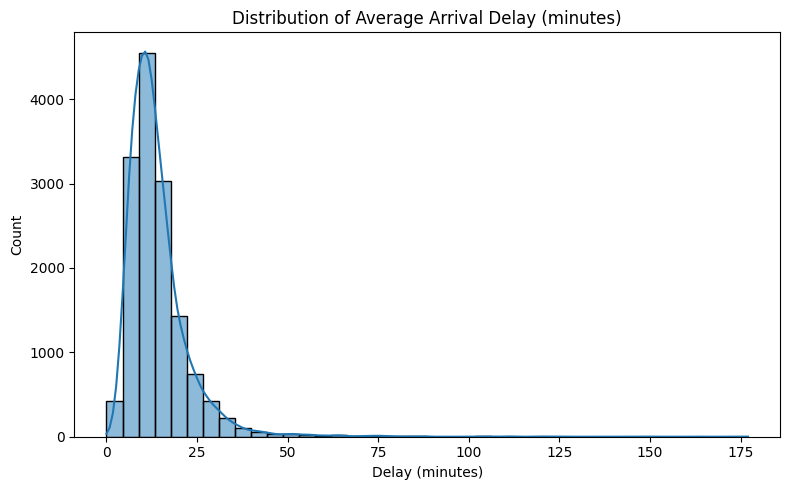

In [50]:
import os
os.makedirs("../figures", exist_ok=True)
plt.figure(figsize=(8, 5))
sns.histplot(df_feat["target_delay_minutes"], bins=40, kde=True)
plt.title("Distribution of Average Arrival Delay (minutes)")
plt.xlabel("Delay (minutes)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../figures/hist_delay_minutes.png", dpi=200)
plt.show()

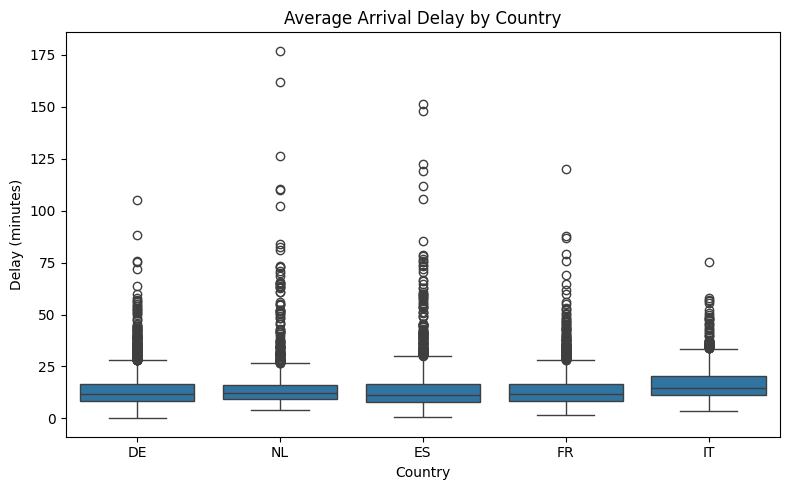

In [51]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_feat, x="iso_country", y="target_delay_minutes")
plt.title("Average Arrival Delay by Country")
plt.xlabel("Country")
plt.ylabel("Delay (minutes)")
plt.tight_layout()
plt.savefig("../figures/box_delay_by_country.png", dpi=200)
plt.show()

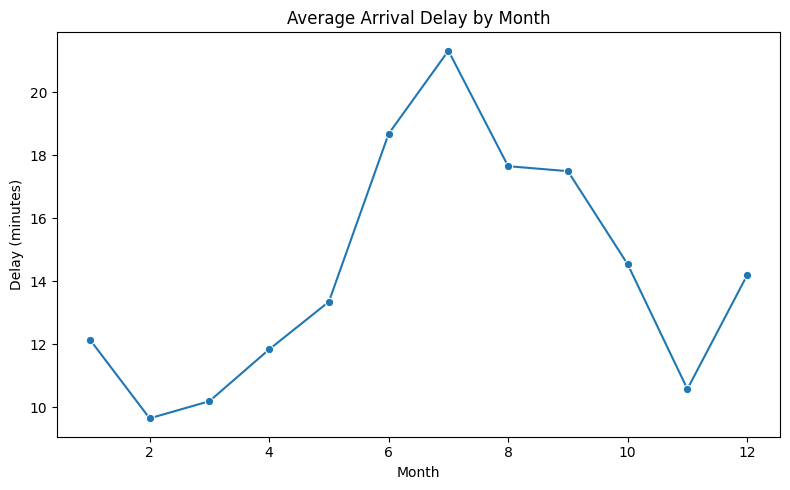

In [52]:
plt.figure(figsize=(8, 5))
monthly = df_feat.groupby("month")["target_delay_minutes"].mean().reset_index()
sns.lineplot(data=monthly, x="month", y="target_delay_minutes", marker="o")
plt.title("Average Arrival Delay by Month")
plt.xlabel("Month")
plt.ylabel("Delay (minutes)")
plt.tight_layout()
plt.savefig("../figures/line_delay_by_month.png", dpi=200)
plt.show()

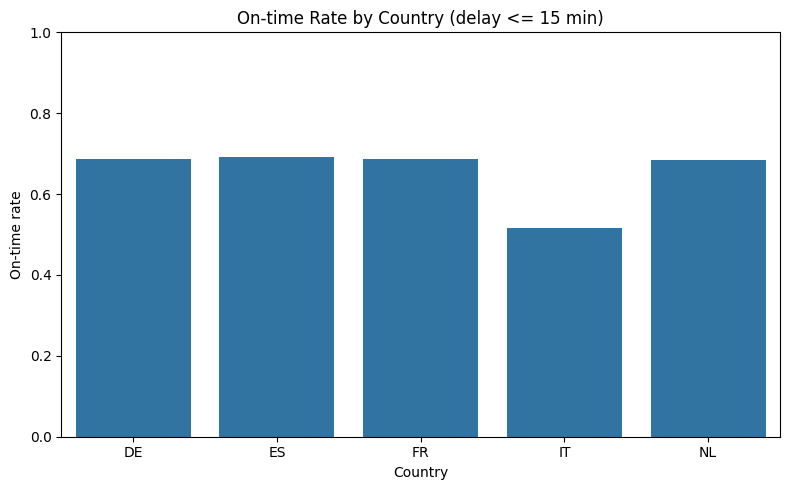

In [53]:
plt.figure(figsize=(8, 5))
rate = (1 - df_feat.groupby("iso_country")["target_delayed_15"].mean()).reset_index(name="on_time_rate")
sns.barplot(data=rate, x="iso_country", y="on_time_rate")
plt.title("On-time Rate by Country (delay <= 15 min)")
plt.xlabel("Country")
plt.ylabel("On-time rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("../figures/bar_ontime_rate_by_country.png", dpi=200)
plt.show()

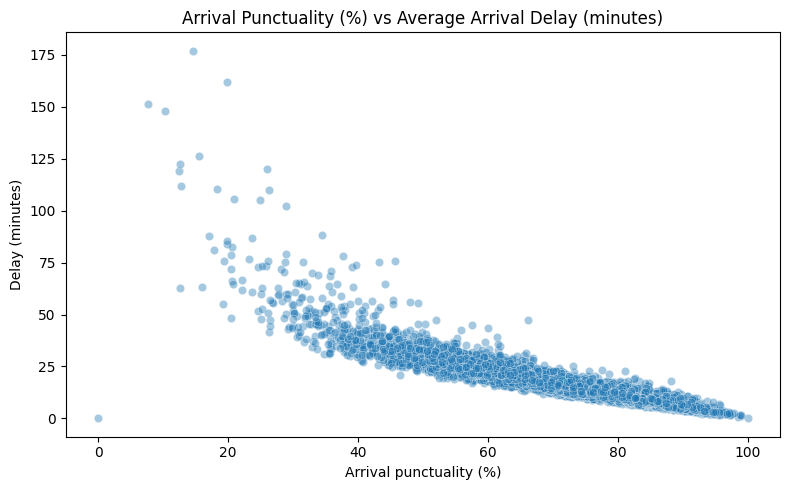

In [54]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_feat, x="arr_punctuality_pct", y="target_delay_minutes", alpha=0.4)
plt.title("Arrival Punctuality (%) vs Average Arrival Delay (minutes)")
plt.xlabel("Arrival punctuality (%)")
plt.ylabel("Delay (minutes)")
plt.tight_layout()
plt.savefig("../figures/scatter_punctuality_vs_delay.png", dpi=200)
plt.show()

## Step 8 - Interpretation of the Visualizations

**1) Histogram - distribution of average arrival delay.**
The distribution is strongly right-skewed: most airport-days have small delays (around 5-15 minutes),
but there is a long tail of larger delays. This means extreme delay days are uncommon but real, and they
pull the mean above the median.
*Limitation:* the target is an **average** delay per airport-day, so it is smoother than individual-flight
delays and hides within-day variation.

**2) Boxplot - delay by country.**
The typical (median) delay is fairly similar across the five countries, but every country shows extreme
outliers reaching very high delays. So "normal" days look alike, but rare disruptions (weather, strikes,
airspace limits) create the big differences.
*Limitation:* country averages hide large airport-to-airport differences.

**3) Line - delay by month.**
Delays rise from late winter into the summer and peak around July, then fall toward autumn. This matches
the idea that summer travel demand puts operational pressure on airports and raises delay risk.
*Limitation:* this mixes all countries and airports together, so individual seasonal patterns may differ.

**4) Bar - on-time rate by country.**
On-time performance differs by country, which suggests country-level factors (congestion, scheduling,
operations) matter. This is useful because `iso_country` then becomes a meaningful model feature.
*Limitation:* the result depends on which airports each country contributes to the dataset.

**5) Scatter - punctuality vs delay.**
There is a clear negative relationship: higher arrival punctuality goes with lower average delay, as
expected. This confirms the two columns measure related things and that punctuality is a strong predictor.
*Limitation:* this is correlation only; we cannot claim causation without weather and traffic controls.

## Step 9 - Save the Final Analytical Dataset

We freeze the cleaned, feature-engineered dataset to `data/processed/` so Phase 4 can load it directly.
The assertions at the end confirm we meet the Phase 3 requirements: **at least 1,000 rows**,
**at least 15 features**, and **at least 5 countries**.

In [55]:
import os
os.makedirs("../data/processed", exist_ok=True)

final_df = df_feat.copy()
out_path = "../data/processed/phase3_airport_day_clean.csv"
final_df.to_csv(out_path, index=False)
id_cols = ["date", "Airport", "iata_code"]
target_cols = ["target_delay_minutes", "target_delayed_15", "target_delay_category"]
n_features = len([c for c in final_df.columns if c not in id_cols + target_cols])

print("Saved:", out_path)
print("Final rows:", final_df.shape[0])
print("Final feature count:", n_features)
print("Countries:", sorted(final_df["iso_country"].unique()))

assert final_df.shape[0] >= 1000, "Row requirement not met (need >= 1000)."
assert n_features >= 15, "Feature requirement not met (need >= 15 features)."
assert final_df["iso_country"].nunique() >= 5, "Country requirement not met (need >= 5)."

Saved: ../data/processed/phase3_airport_day_clean.csv
Final rows: 14462
Final feature count: 22
Countries: ['DE', 'ES', 'FR', 'IT', 'NL']
